In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append("..")
import gp
import pickle
import matplotlib.pyplot as plt
import numpy as np
from pandas import DataFrame
import openpyxl
import math
# Making table for testing masses. Currently gives lots of inf values for unknown reason.
mass_hypothesis = .100
mass_hypotheses = np.linspace(.015,.120,106).tolist()
rebin = 1
# Coefficients for the polynomial from the table for unsmeared (P0 to P4)
#coefficients = [0.00032, 0.019, -0.11, 1.39, -4.33]

#2015 Coefficients
coefficients = [0.000579,-0.00297,0.9069,-6.166];


def sigma(mass, coeffs):
    #sigma is twice the mass resolution
    return sum(c * mass**i for i, c in enumerate(coeffs))

def sigmas(masses, coeffs):
    sigma_list = []
    for mass in masses:
        sigma_list.append(sum(c * mass**i for i, c in enumerate(coeffs)))
    return sigma_list

'''
def make_table(masses, coeffs):
    sigma_list = sigmas(masses, coeffs)
    ul_list = []
    for i in range(len(masses)):
        
        m = gp.GaussianProcessModel(
            h = 'EventSelection_Data_10Percent.root', # use real IMD from ROOT file in this directory
            kernel = gp.kernels.Product(gp.kernels.RBF(), gp.kernels.DotProduct()),
            #kernel = gp.kernels.RBF(),
            blind_range = (masses[i]-(sigma_list[i]), masses[i]+(sigma_list[i])),
            #modify_histogram = [gp._hist.manipulation.rebin_and_limit(10, 0.033, 0.179), gp._hist.manipulation.inject_signal(5000,sigma(mass_hypothesis, coefficients),mass_hypothesis)]
            modify_histogram = gp._hist.manipulation.rebin_and_limit(10, 0.035, 0.179)
        )
        m.model
        m.model.kernel_
        ul_list.append(m.upper_limit_in_blind_region())
    return ul_list
    '''
def make_table(masses, coeffs):
    sigma_list = sigmas(masses, coeffs)
    ul_list = []
    for i in range(len(masses)):
        # Print blind range for debugging
        blind_range = (masses[i] - sigma_list[i], masses[i] + sigma_list[i])
        print(f"Mass: {masses[i]}, Sigma: {sigma_list[i]}, Blind Range: {blind_range}")
        
        try:
            # Create the model with the current mass and blind range
            m = gp.GaussianProcessModel(
                h = ('invariant_mass_0pt5mm_full.root', 'invariant_mass'),
                kernel = gp.kernels.WhiteKernel() + gp.kernels.RBF() * gp.kernels.DotProduct(),
                blind_range = blind_range,
                modify_histogram = gp._hist.manipulation.rebin_and_limit(rebin, 0.015, 0.120)
            )
            # Calculate upper limit
            upper_limit = m.upper_limit_in_blind_region()
        except Exception as e:
            print(f"Error for mass {masses[i]}: {e}")
            upper_limit = float('inf')  # or a fallback value

        ul_list.append(upper_limit)

    return ul_list, sigma_list

ul1, sl = make_table(mass_hypotheses, coefficients)
# Put table in Excel file

df = DataFrame({'Mass': mass_hypotheses, 'Blind Range Size': [i*2 for i in sl], 'Upper Limit': ul1})
df.to_csv('ul_test.csv', index=False)


Mass: 0.015, Sigma: 0.00071769225, Blind Range: (0.014282307749999999, 0.015717692249999998)
Mass: 0.016, Sigma: 0.000738390464, Blind Range: (0.015261609536, 0.016738390464)
Mass: 0.017, Sigma: 0.0007603105419999999, Blind Range: (0.016239689458, 0.017760310542000002)
Mass: 0.018, Sigma: 0.000783415488, Blind Range: (0.017216584511999998, 0.018783415488)
Mass: 0.019, Sigma: 0.000807668306, Blind Range: (0.018192331694, 0.019807668306)
Mass: 0.02, Sigma: 0.000833032, Blind Range: (0.019166968, 0.020833032)
Mass: 0.020999999999999998, Sigma: 0.000859469574, Blind Range: (0.020140530426, 0.021859469573999996)
Mass: 0.022, Sigma: 0.000886944032, Blind Range: (0.021113055967999998, 0.022886944032)
Mass: 0.023, Sigma: 0.0009154183779999999, Blind Range: (0.022084581622, 0.023915418378)
Mass: 0.024, Sigma: 0.000944855616, Blind Range: (0.023055144384, 0.024944855616)
Mass: 0.025, Sigma: 0.0009752187500000001, Blind Range: (0.024024781250000002, 0.02597521875)
Mass: 0.026, Sigma: 0.0010064707

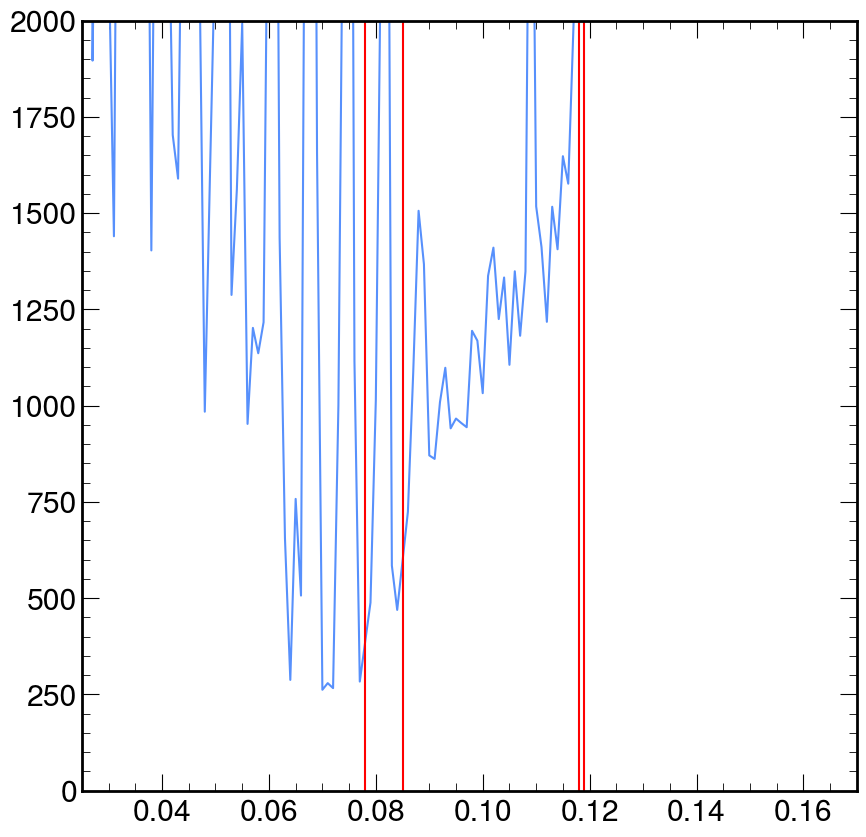

In [2]:
plot_ul = []
plot_masses = []
error_list = []
for i in range(len(ul1)):
    if not math.isinf(ul1[i]):
        plot_ul.append(ul1[i])
        plot_masses.append(mass_hypotheses[i])
    else:
        error_list.append(mass_hypotheses[i])

plt.plot(plot_masses, plot_ul, label='Upper Limit vs Mass')
plt.vlines(error_list, 0, 8000, 'r')
ax1 = plt.gca()
ax1.set_xlim([.025, .170])
ax1.set_ylim([0, 2000])
df2 = DataFrame({'Mass': plot_masses, 'Upper Limit': plot_ul})
df2.to_csv('ul_test_fixed.csv', index=False)